# Experimenting with image segmentation model

## Setup environment

In [1]:
!python --version
!pip --version

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [2]:
!pip install fastai "fastcore < 2.0"

## Prepare Data
> Subset of ***CamVid dataset*** from the paper ***"Semantic Object Classes in Video: A High-Definition Ground Truth Database"***

In [3]:
from fastai.vision.all import *

path = untar_data(URLs.CAMVID_TINY)
print(f"path to camvid data: {path}")

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:01&lt;00:00]</div>

path to camvid data: /root/.fastai/data/camvid_tiny


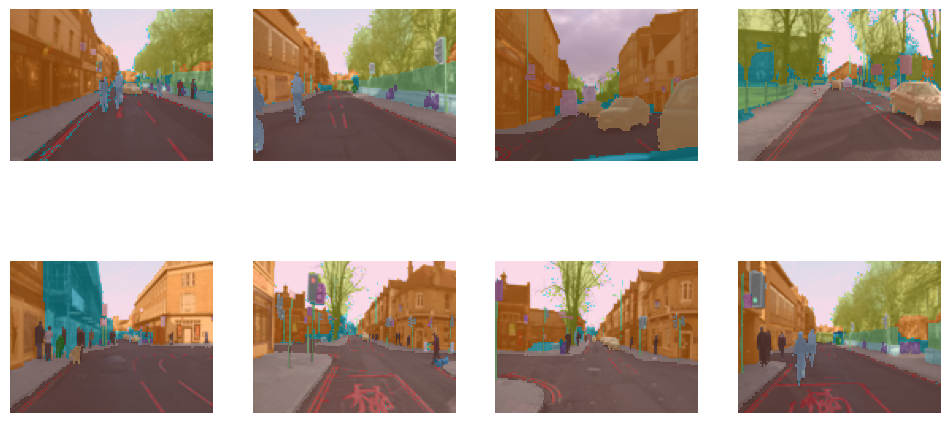

In [4]:
dls = SegmentationDataLoaders.from_label_func(
  path, bs=8, fnames = get_image_files(path/"images"),
  label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
  codes = np.loadtxt(path/'codes.txt', dtype=str), seed=42
)

dls.show_batch(max_n=9)

## Training Model

In [5]:
import torch
torch.cuda.empty_cache()

learn = unet_learner(dls, resnet50)
learn.fine_tune(15)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


epoch,train_loss,valid_loss,time
0,4.580315,5.358557,00:10


epoch,train_loss,valid_loss,time
0,2.160424,1.900751,00:09
1,1.834428,1.358202,00:09
2,1.627231,1.199228,00:09
3,1.461175,1.169750,00:09
4,1.353035,1.272041,00:09
5,1.342481,1.167372,00:10
6,1.279726,1.055364,00:10
7,1.195516,0.864744,00:10
8,1.105946,0.795847,00:10
9,1.019865,0.729608,00:10


## Display Result

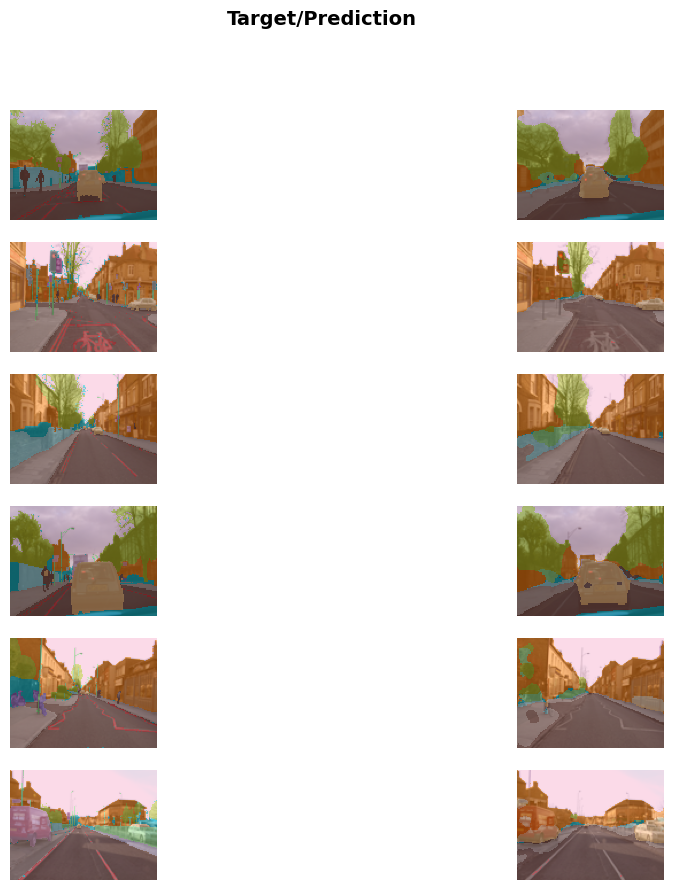

In [6]:
learn.show_results(max_n=6, figsize=(12,10))